In [1]:
import pandas as pd
import glob
import json
import os

sample_path = f'{os.getcwd()}/../workspace/samples/'

x86_samples = 'x86-gemini-pro'
arm_samples = 'arm-gemini-pro'

def get_rows(path):

    summaries = sorted(glob.glob(f'{path}/*/agent_repair/summary.json'))

    rows = []
    for sample, path in enumerate(summaries):

        with open(path, 'r') as f:
            data = json.load(f)
        
        arch = data['summary']['arch']
        model = data['models']['llm']

        for attempt in data['attempts']:
            rows.append({
                'sample': sample,
                'arch': arch,
                'model': model,
                'attempt': attempt['attempt'],
                'klocalizer_status': attempt['summary']['klocalizer_status'],
                'build_succeeded': attempt['summary']['build_succeeded'],
                'boot_succeeded': attempt['summary']['boot_succeeded'],
            })

    return rows

rows = get_rows(f'{sample_path}/{x86_samples}') + get_rows(f'{sample_path}/{arm_samples}')
df = pd.DataFrame(rows)

df['arch'] = df['arch'].apply(lambda x: 'x86' if 'x86' in x else 'ARM')

print(df.groupby('model')['sample'].nunique())

df.head()

model
gemini-3.1-pro-preview    50
Name: sample, dtype: int64


,sample,arch,model,attempt,klocalizer_status,build_succeeded,boot_succeeded
0,0,x86,gemini-3.1-pro-preview,0,not-run,False,no
1,0,x86,gemini-3.1-pro-preview,1,success,True,timeout
2,0,x86,gemini-3.1-pro-preview,2,success,True,panic
3,0,x86,gemini-3.1-pro-preview,3,success,True,timeout
4,0,x86,gemini-3.1-pro-preview,4,success,True,panic


In [25]:
attempts_per_sample = df.groupby(['arch', 'sample'])['attempt'].max().reset_index()

x86_samples = attempts_per_sample[attempts_per_sample['arch'] == 'x86']['attempt']
arm_samples = attempts_per_sample[attempts_per_sample['arch'] == 'ARM']['attempt']

print(attempts_per_sample.groupby('arch')['attempt'].describe().to_string())

print()

print('Overall:')
print(attempts_per_sample['attempt'].describe().to_string())

      count  mean       std  min   25%  50%    75%   max
arch                                                    
ARM    50.0  9.64  4.392758  3.0  6.25  9.0  12.75  20.0
x86    50.0  9.74  5.058071  2.0  6.00  8.5  11.00  20.0

Overall:
count    100.000000
mean       9.690000
std        4.713392
min        2.000000
25%        6.000000
50%        9.000000
75%       12.000000
max       20.000000


# Success Rate vs Attempt

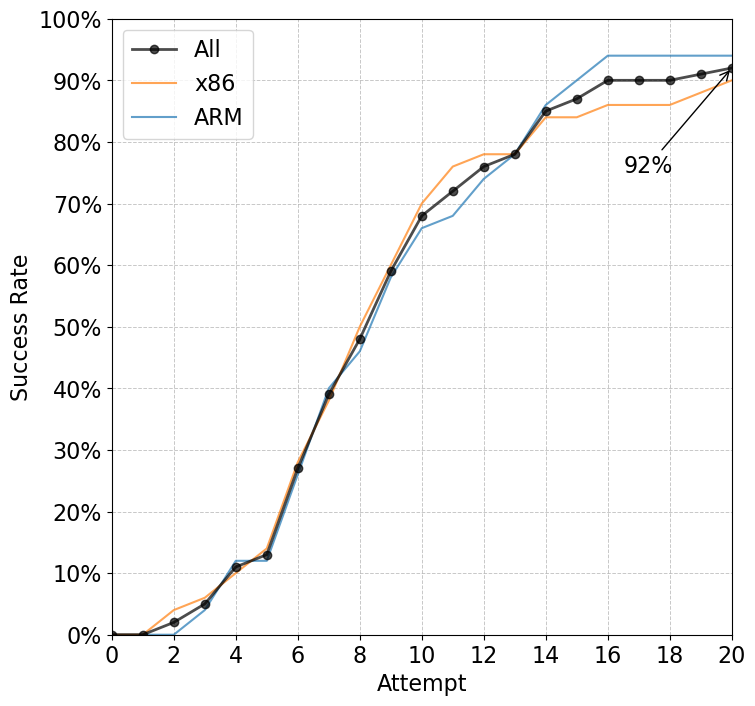

In [26]:
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

ax.set_xlabel('Attempt', fontsize=16)
ax.set_ylabel('Success Rate', fontsize=16)

ax.set_xlim(0, 20)
ax.set_ylim(0, 1)

ax.set_xticks(range(0, 21, 2))
ax.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis='both', labelsize=16)
ax.grid(True, alpha=0.7, linestyle='--', linewidth=0.7)

for (model, arch), attempts in df.groupby(['model', 'arch']):
    total = attempts['sample'].nunique()
    first_success = attempts[attempts['boot_succeeded'] == 'yes'].groupby('sample')['attempt'].min()
    max_attempt = attempts['attempt'].max()

    rates = [(first_success <= n).sum() / total for n in range(max_attempt + 1)]
    ax.plot(range(max_attempt + 1), rates, label=arch, alpha=0.7)

for model, attempts in df.groupby('model'):
    total = attempts.groupby(['arch', 'sample']).ngroups
    first_success = (attempts[attempts['boot_succeeded'] == 'yes']
                     .groupby(['arch', 'sample'])['attempt'].min())
    max_attempt = attempts['attempt'].max()

    rates = [(first_success <= n).sum() / total for n in range(max_attempt + 1)]
    ax.plot(range(max_attempt + 1), rates, marker='o', label='All', alpha=0.7, linewidth=2, color='black')

ax.annotate('92%', xy=(20, 0.92), xytext=(16.5, 0.75), arrowprops=dict(color='black', arrowstyle='->'), fontsize=16)

handles, labels = ax.get_legend_handles_labels()
ax.legend([handles[-1]] + handles[:-1][::-1], [labels[-1]] + labels[:-1][::-1], fontsize=16)
plt.savefig('success-rates.pdf', format='pdf')
plt.show()


In [27]:
attempts_per_sample = df.groupby(['arch', 'sample'])['attempt'].max()

print(attempts_per_sample.groupby('arch').describe())

print()

for attempts in [5, 10, 14, 15, 16, 17, 20]:
    print(f'Attempts <= {attempts}: {(attempts_per_sample <= attempts).sum() / attempts_per_sample.count():.2%}')

print()

print(attempts_per_sample.describe())

      count  mean       std  min   25%  50%    75%   max
arch                                                    
ARM    50.0  9.64  4.392758  3.0  6.25  9.0  12.75  20.0
x86    50.0  9.74  5.058071  2.0  6.00  8.5  11.00  20.0

Attempts <= 5: 13.00%
Attempts <= 10: 68.00%
Attempts <= 14: 85.00%
Attempts <= 15: 87.00%
Attempts <= 16: 90.00%
Attempts <= 17: 90.00%
Attempts <= 20: 100.00%

count    100.000000
mean       9.690000
std        4.713392
min        2.000000
25%        6.000000
50%        9.000000
75%       12.000000
max       20.000000
Name: attempt, dtype: float64


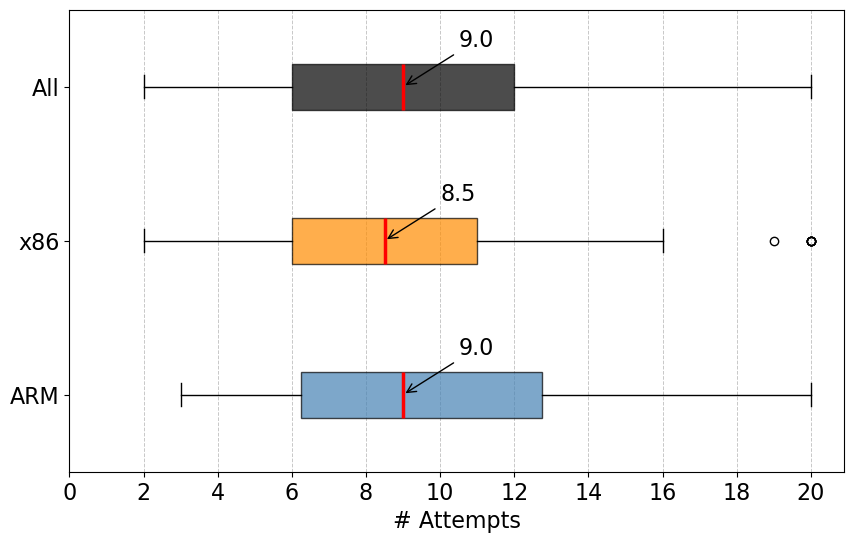

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))                                   

ax.set_xlabel('# Attempts', fontsize=16)

groups = [(arch, group.groupby('sample')['attempt'].max().values)
        for arch, group in df.groupby('arch')]

overall_attempts = df.groupby(['arch', 'sample'])['attempt'].max().values
groups.append(('All', overall_attempts))

labels, data = zip(*groups)
colors = ['steelblue', 'darkorange', 'black']

bp = ax.boxplot(data, labels=labels, patch_artist=True, vert=False)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, median in enumerate(bp['medians']):
    median.set_color('red')
    median.set_linewidth(2.5)

    x = median.get_xdata()[1]
    y = i + 1

    ax.annotate(f'{x:.1f}', xy=(x, y), xytext=(x + 1.5, y + 0.3), fontsize=16, color='black', va='center', arrowprops=dict(arrowstyle='->', color='black'))

ax.grid(axis='x', linestyle='--', linewidth=0.7, alpha=0.7)
ax.tick_params(axis='both', labelsize=16)
ax.set_xticks(range(0, 21, 2))
ax.set_axisbelow(True)

plt.savefig('attempt-distribution.pdf', format='pdf', bbox_inches='tight')
plt.show()